This Jupyter notebook aims to produce a clean csv of annotations for a canary wave file.
1. Annotating the data by using a model trained with canapy
2. Aggregating the annotations to have a duration in seconds format for each syllable
3. Exporting a csv corresponding to the wav file

In [3]:
from canapy import Dataset, Annotator
from collections import defaultdict
import glob
import itertools
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from Levenshtein import distance as levenshtein_distance
import sklearn

AttributeError: module 'pandera' has no attribute 'SchemaModel'

## Annotating the data by using a model trained with canapy

Change the path below according to the dataset of wav files you want to annotate.

In [ ]:
path='/home/broca/Albane/datasets/rouge6/rouge6_wo_annotation/072013/'

In [23]:
dataset = Dataset(path)

Change the path below according to the model you want to use to annotate the wave file.

In [24]:
annotator = Annotator("/home/broca/Albane/datasets/rouge6/rouge6_annotated/output_0_2_3_post1/models", dataset=dataset)

Annotate with the run() canapy function.

In [25]:
annotations, vectors = annotator.run()

Processing data for syn training: 100%|██████████| 86/86 [01:45<00:00,  1.23s/it]
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    1.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    1.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    1.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    1.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[

[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Usin

[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Usin

[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Usin

[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Usin

Visualize the annotations produced for each time frame.

In [ ]:
print(annotations['syn'])

##  Comparing two sequences


This part is designed to compare the predictions of two models. The sequences produced by the two models are compared, meaning we get a comparison matrices that give similar predictions statistics for the syllables predicted by at least of of the two models.

In [6]:
songs_syn = list(annotations["syn"].keys())
syll_comp={}

for song in songs_syn:
    seq_syn= annotations["syn"][song]
    seq_nsyn= annotations["nsyn"][song]
    
    for i,syll in enumerate(seq_syn):
        if syll not in syll_comp.keys():
            syll_comp[syll]=[]

        # For each syllable predicted in the first sequence we verify if 
        # the second model has made the same prediction or not.
        if seq_nsyn[i] != syll:
            syll_comp[syll].append(False)
        else:
            syll_comp[syll].append(True)
            

print(syll_comp.keys())
labels = list(syll_comp.keys())
    

dict_keys(['SIL', 'Ti', 'Z', 'cri', 'S1', 'A1', 'T', 'B', 'E2', 'Y', 'E1', 'S2', 'A2', 'St2', 'C', 'P2', 'P1', 'X', 'F', 'U', 'V', 'St', 'G'])


In [ ]:
# songs_syn = list(annotations["syn"].keys())
# syll_comp=[]

# for song in songs_syn:    
#     for syll in seq_syn:
#         if syll not in syll_comp.keys():
#             syll_comp.append(syll)
            
# print(syll_comp)
# labels = syll_comp

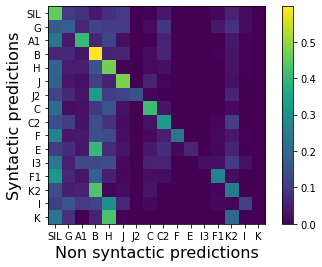

In [7]:
songs_syn = list(annotations["syn"].keys())
seq_syn=[]
seq_nsyn=[]

for song in songs_syn:
    syn= annotations["syn"][song]
    nsyn= annotations["nsyn"][song]
    for frame in syn:
        seq_syn.append(frame)
    for frame in nsyn:
        seq_nsyn.append(frame)
    
# To the two predicted sequences we apply the confusion matrix methood of sklearn to get a visual representation.
comp_matrix=sklearn.metrics.confusion_matrix(y_true=seq_syn, y_pred=seq_nsyn,labels=labels,normalize='true')
disp = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=comp_matrix,display_labels=labels)
disp.plot(include_values=False)
plt.rcParams["figure.figsize"] = (100,10)

plt.xlabel('Non syntactic predictions', fontsize=16)
plt.ylabel('Syntactic predictions', fontsize=16)
plt.savefig('/home/broca/Albane/datasets/j12o12/j12o12_wo_annotation/j12o12_comp_mat_march_30_31_true.jpg')

plt.show()

## Aggregating the annotations to have a duration in seconds format for each syllable

In [ ]:
def group_frames(seq, min_frame_nb=5):
    """We build new sequence containing the syllables grouped by type. To do so we push the sequence through 
    a selecting window of odd length, the syllables which appears the most in the time frames in the window 
    is selected. If two syllables appear at the same amount we look in its vicinity.
    """

    win_length = min_frame_nb * 2 + 1

    new_seq = [None] * (len(seq) - win_length + 1) 
    #size of the sequence minus size of the window plus the center part/frame of it
    if len(new_seq)<=0:
        return [],0
        
    else:
        for i in range(len(new_seq)):  
            win = np.roll(seq, shift=-i)[:win_length] 

            groups = [(k, len(list(g))) for k, g in itertools.groupby(win)] 
            #for each window, name of the syllables and number of apparition
            lengths = defaultdict(int)
            for g in groups:#for each syllable and its number of apparition

                lengths[g[0]] += g[1] #number of vote for each syllable in a window 

            max_keys = [key for key, value in lengths.items() if value == max(lengths.values())] 
            #syllables which appear the most in the window
            new_seq[i] = max_keys 

        new_seq = [new_seq[0]] * (win_length//2) + new_seq + [new_seq[-1]] * (win_length//2) #to have the same length 
        #of the inital sequence we copy the first and the last items at the start and at the end of the new sequence

        gp_new_seq = [[k, len(list(g))] for k, g in itertools.groupby(new_seq)] 
        #first groupby to group juxtaposed frame for the same syllable
        length_new_seq= len(new_seq)

        #then, for each window where syllables are too short or different syllables are equally present we look to 
        #the environnent group and choose the syllable which is the longest
        syll_prec=gp_new_seq[0]
        final_seq=gp_new_seq
        for i,frame in enumerate(gp_new_seq):
            if frame[1]< min_frame_nb and i+1<= len(new_seq):
                syll_suiv=gp_new_seq[i+1]

                if syll_prec[1] > syll_suiv[1]:
                    if isinstance(syll_prec[0],str)==True:
                        final_seq[i][0]=syll_prec[0]
                    else :
                        final_seq[i][0]=syll_prec[0][0]

                else:
                    if isinstance(syll_suiv[0],str)==True:
                        final_seq[i][0]=syll_suiv[0]
                    else :
                        final_seq[i][0]=syll_suiv[0][0] 

            else:
                final_seq[i][0]= final_seq[i][0][0]
                final_seq[i][1]= gp_new_seq[i][1]
                syll_prec=gp_new_seq[i]

        #print(final_seq)

        #here is a handmade groupby to group the old 'hesitant' window to the initial ones
        agg_final = []
        prec=None
        compteur=-1
        for syll,length in final_seq:
            if syll==prec:

                agg_final[compteur][1] += length
            else:
                agg_final.append([syll,length])
                prec=syll
                compteur+=1

        #print(agg_final)
        return agg_final,len(agg_final)


Apply the above function to the dataset and build dataframes to export. Don't forget to modify the number minimum of frames depending on your dataset.

In [28]:
sr = 44100
hop = 512

songs = list(annotations["nsyn"].keys())

for song in songs:
    seq, l = group_frames(annotations["nsyn"][song],min_frame_nb=5) 
    
    if l==0:
        msg= str("This song:" +song+" is too short, a csv won't be provided for it.")
        print(msg)
    
    else:

        durations = { "start": [], "end": [],"syll": [],"frames":[]}
        onset = 0.0
        for s in seq:
            end = onset + (s[1] * (hop / sr))
            if s[0] != 'SIL':
                durations["syll"].append(s[0])
                durations["end"].append(round(end, 4))
                durations["start"].append(round(onset, 4))
                durations["frames"].append(s[1]) 
            onset = end

        df=pd.DataFrame(durations)
        #print(df)
        song=song[:-4]

        file_name= str("/home/broca/Albane/datasets/rouge6/rouge6_wo_annotation/072013_predictions/nsyn/"+song+".csv")
        df.to_csv(file_name)
    

To aggregate annotations from CSV files, use the code indicated in the **Testing the aggregation process** part

## Testing the aggregation process

This part was only designed to test the impact of the function, you don't need to execute it if you don't modify the code.

We take some already annotated wave csv, put them back into frame format and pass them through data aggragation function to verify if it works well.

In [11]:
sr = 44100
hop = 512

data_init=glob.glob("/home/broca/Albane/datasets/marron1/marron1_annotated/M1-2016-spring_annotations/annotations/*.csv")

#we create two arrays to vizualize the difference between the initial csv/dataframe and the one produced
hist_start=[]
hist_end=[]
#print(len(data_init))
for csv_path in data_init:
    
    df_init= pd.read_csv(csv_path)
    df_init_d=df_init.drop(['wave'],axis=1)
    
    #not all annotated by hand files have silence indications, as we produce csv without the silence "syllables", 
    #it is best for comparing to deprive the original files of the lines of silence
    df_init_s=df_init_d.copy()
    for line in df_init_s.index:
        if df_init_s['syll'][line] == 'SIL':
            df_init_s=df_init_s.drop(line)
    #print(df_init_s)
            
    #the initial csv timestamps are expressed in seconds, we discretize them to get corresponding frames
    df_init_sp=df_init_s.copy()
    df_init_sp['start']=np.round(df_init_s['start']*sr)//hop
    df_init_sp['end']=np.round(df_init_s['end']*sr)//hop
    #print(df_init_sp)
    
    #building of the sequence based on the timestamps and the corresponding syllables
    #when there is no sound the model predicts a "syllable" silence "SIL"
    seq=[]
    end_prec=0
    for line in df_init_sp.index:
        if end_prec != df_init_sp['start'][line]:
            nb_sil=df_init_sp['start'][line]-end_prec
            seq.extend('SIL'for i in range(int(nb_sil)))
            
        
        nb_syll=df_init_sp['end'][line]-df_init_sp['start'][line]
        seq.extend(df_init_sp['syll'][line] for i in range(int(nb_syll)))
        end_prec=df_init_sp['end'][line]

    #simulating the creation of a csv based on a sequence of annotations for each time frame
    new_seq, l = group_frames(seq,3)
    durations = { "start": [], "end": [],"syll": [],"frames":[]}
    onset = 0.0
    for s in new_seq:
        
        end = onset + (s[1] * (hop / sr))
        
        if s[0] != 'SIL':
            durations["syll"].append(s[0])
            durations["end"].append(round(end, 3))
            durations["start"].append(round(onset, 3))
            durations["frames"].append(s[1])
        onset = end

            
    df=pd.DataFrame(durations)
    #print(df)
    csv_filename=os.path.basename(csv_path)
    new_csv_path= str("/home/broca/Albane/datasets/marron1/marron1_annotated/aggregated_annotations/aggregated_"+csv_filename)
    df.to_csv(new_csv_path)
    
    #we calculate the difference between the start and the end of each syllable in the initial 
    #dataframe/csv and the one produced, as sometimes initial csv contained similar syllables juxtaposed,
    #their can be a shift if we compare the two dataframes line by line, thus we comapere the timestamps
    #of the initial dataframe/csv to the closer one in the produced dataframe/csv
    dist=[]
    for init_start in df_init_s['start']:
        dist.append(abs(df['start']- init_start)) 
    min_dist=np.amin(dist)
    hist_start.append(min_dist)
    
    dist=[]
    for init_end in df_init_s['end']:
        dist.append(abs(df['end']- init_end)) 
    min_dist=np.amin(dist)
    hist_end.append(min_dist)


Finally we build histograms to see if the difference between start and end of the syllables are too significant. Those tested where way inferior to the duration of a frame in secoonds, meaning the function has no side effect of shifting.

Text(0.5, 1.0, 'Difference between the starts of syllables after aggregation')

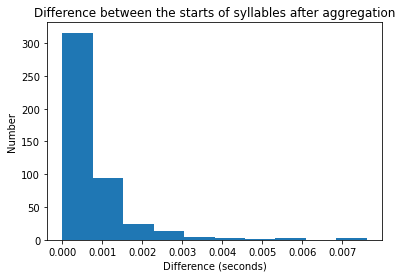

In [7]:
plt.hist(hist_start)
plt.xlabel('Difference (seconds)')
plt.ylabel('Number')
plt.title('Difference between the starts of syllables after aggregation')

Text(0.5, 1.0, 'Difference between the ends of syllables after aggregation')

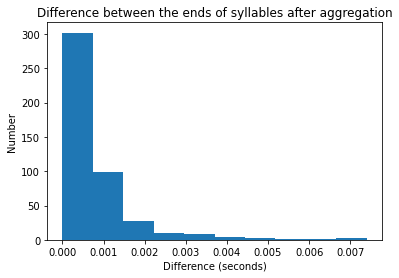

In [8]:
plt.hist(hist_end)
plt.xlabel('Difference (seconds)')
plt.ylabel('Number')
plt.title('Difference between the ends of syllables after aggregation')

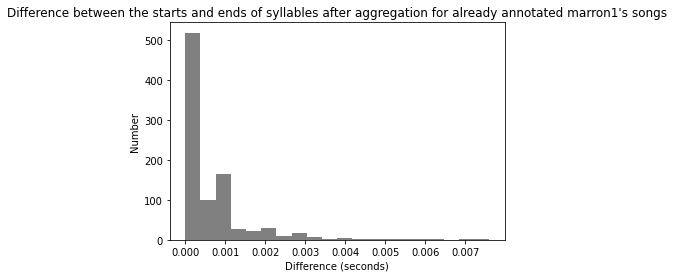

In [10]:
hist_ensemble=hist_start+hist_end
plt.hist(hist_ensemble,color=['gray'],bins=20)
plt.xlabel('Difference (seconds)')
plt.ylabel('Number')
plt.title("Difference between the starts and ends of syllables after aggregation for already annotated marron1's songs")

plt.savefig("hist_agg_marron1.png")
plt.savefig("hist_agg_marron1.pdf")

In [ ]:
hist_ensemble=hist_start+hist_end
plt.hist(hist_ensemble,color=['gray'],bins=20)
plt.xlabel('Difference (seconds)')
plt.ylabel('Number')
plt.title("Difference between the starts and ends of syllables after aggregation for already annotated marron1's songs")

plt.savefig("hist_agg_marron1_prox.png")
plt.savefig("hist_agg_marron1_prox.pdf")

In [ ]:
hist_ensemble=hist_start+hist_end
plt.hist(hist_ensemble,color=['gray'])
plt.xlabel('Difference (seconds)')
plt.ylabel('Number')
plt.title("Difference between the starts and ends of syllables after aggregation for already annotated j12o12's songs")')

plt.savefig("hist_agg_j12o12.png")
plt.savefig("hist_agg_j12o12.pdf")